In [3]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
dataset = "room dataset"

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "SplitDataset/train",
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "SplitDataset/val",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
    )

test_ds = tf.keras.utils.image_dataset_from_directory(
    "SplitDataset/test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 2620 files belonging to 11 classes.
Found 558 files belonging to 11 classes.
Found 573 files belonging to 11 classes.


In [6]:
print(train_ds.class_names)


['bathroom', 'bedroom', 'closet', 'corridor', 'dining_room', 'garage', 'kitchen', 'livingroom', 'lobby', 'office', 'pantry']


In [7]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


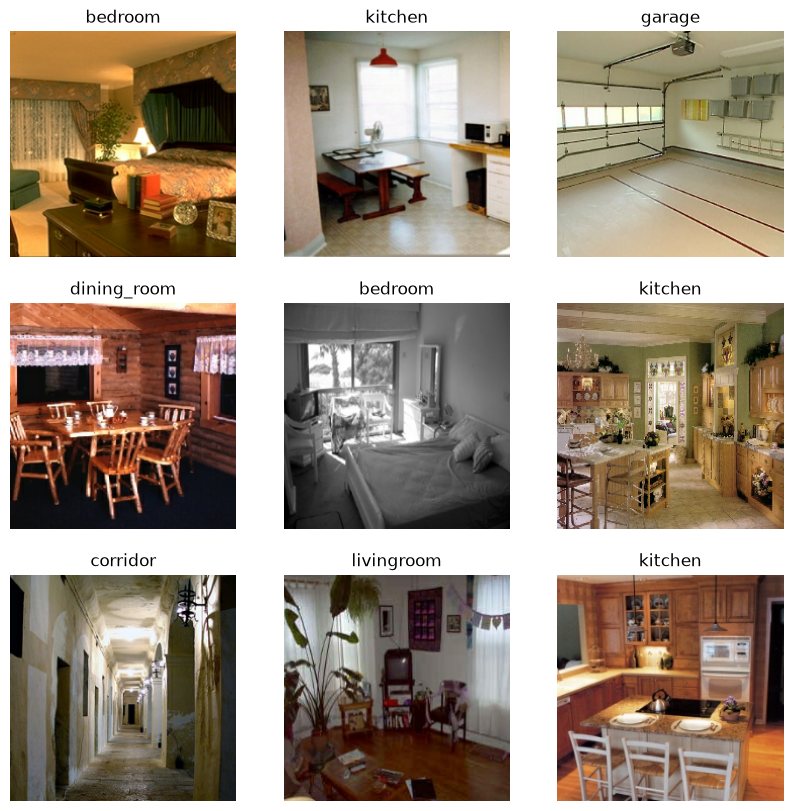

In [8]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_ds.class_names[labels[i]])

        plt.axis("off")

plt.show()

**Data Augmentation**

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

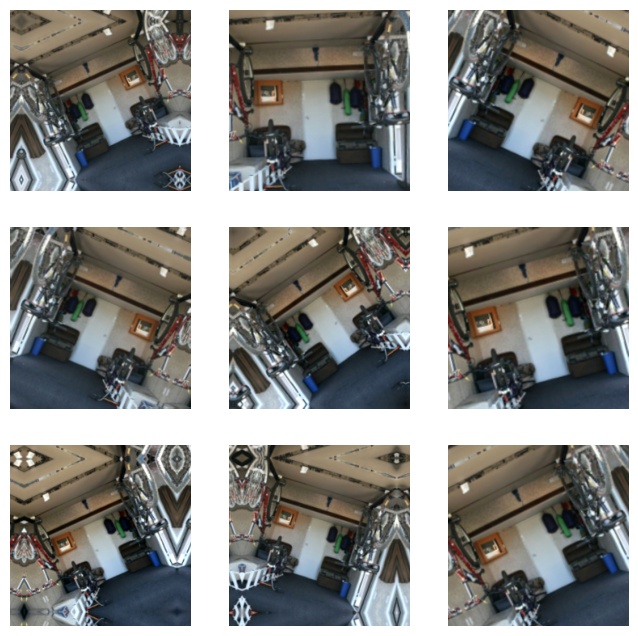

In [10]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        augmented = data_augmentation(tf.expand_dims(first_image,0))

        plt.imshow(augmented[0].numpy().astype("uint8"))
        
        plt.axis("off")

plt.show()

In [11]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights = "imagenet",
    include_top = False,
    input_shape = (224, 224, 3)
)

In [12]:
from tensorflow.keras import layers, Model

input = layers.Input(shape = (224,224,3))

x = data_augmentation(input)

x = base_model(x, training = False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

output = layers.Dense(11, activation="softmax")(x)

model = Model(input, output)

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics= ["accuracy"]
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.7260 - loss: 0.8766 - val_accuracy: 0.7294 - val_loss: 1.0391
Epoch 2/50
37/82 ━━━━━━━━━━━━━━━━━━━━ 1:47 2s/step - accuracy: 0.8243 - loss: 0.5497

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")

2.21.0


In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: []
